# Stiff ODEs & index-1 DAEs, staying on the constraint manifold

`pounce.ode.solve_ivp` is a drop-in for `scipy.integrate.solve_ivp(method="Radau")`
(3-stage Radau IIA, order 5, L-stable) with one extra power: a **mass matrix**
`M y' = f`. When `M` is **singular** the zero rows are pure algebraic
constraints `0 = f_alg(t, y)`, so the same solver integrates an **index-1
differential–algebraic equation (DAE)** — something SciPy's `solve_ivp` cannot do.

This notebook is about a subtlety of DAEs that is easy to get silently wrong:
**keeping the reported solution on the constraint manifold**. Two knobs handle
the two places it can drift, one per GitHub issue:

- **`consistent="project"`** (default, [gh #215](https://github.com/jkitchin/pounce/issues/215)) — projects an inconsistent *initial* condition onto `0 = f` before integrating.
- **`project_output=True`** (opt-in, [gh #216](https://github.com/jkitchin/pounce/issues/216)) — Newton-polishes each requested *output* point back onto the manifold.

The companion diagnostic script is
[`python/examples/dae_manifold_gap.py`](../examples/dae_manifold_gap.py); point
its `manifold_gap()` at your own DAE.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pounce
import pounce.ode as po
print("pounce", pounce.__version__)

pounce 0.9.0


## 1. A tiny index-1 DAE

Take a differential state `y0` that decays, and an algebraic state `y1` that is
*slaved* to it by a nonlinear constraint:

$$ y_0' = -y_0, \qquad 0 = y_1 - y_0^2. $$

`M = diag(1, 0)`: the second row is zero, so the second equation is the
algebraic constraint. The exact solution is `y0 = e^{-t}`, `y1 = e^{-2t}`.

In [2]:
def f(t, y):
    return [-y[0], y[1] - y[0] ** 2]

M = np.diag([1.0, 0.0])   # second equation is algebraic (0 = y1 - y0**2)

res = po.solve_ivp(f, (0.0, 2.0), [1.0, 1.0], mass=M, rtol=1e-8, atol=1e-10,
                   dense_output=True)
tt = np.linspace(0, 2, 200)
Y = res.sol(tt)
print("solved:", res.success, "| steps:", res.nstep)
print("max error vs exact:",
      max(np.max(np.abs(Y[0] - np.exp(-tt))), np.max(np.abs(Y[1] - np.exp(-2 * tt)))))

solved: True | steps: 80
max error vs exact: 4.959083699240807e-09


## 2. Inconsistent initial conditions are projected (gh #215)

The whole point of an algebraic variable is that it is **determined** by the
differential ones — so a *rough guess* for it is the normal thing to pass. Here
`y0 = 1` forces `y1 = 1`, but we deliberately pass `y1 = 5`, which is off the
manifold (`y1 - y0**2 = 4 ≠ 0`).

By default `solve_ivp` projects `y0` onto `0 = f` before integrating — exactly
what `solve_dae` does — so `res.y[:, 0]` is a state the model actually admits.

In [3]:
bad_ic = [1.0, 5.0]   # 0 = y1 - y0**2 wants y1 = 1, not 5

r_proj = po.solve_ivp(f, (0.0, 2.0), bad_ic, mass=M, rtol=1e-8, atol=1e-10)
r_asis = po.solve_ivp(f, (0.0, 2.0), bad_ic, mass=M, consistent="assume",
                      rtol=1e-8, atol=1e-10)

for label, r in [("project (default)", r_proj), ("assume (opt out)", r_asis)]:
    y0 = r.y[:, 0]
    print(f"{label:<18} y(0) = {y0}   |y1 - y0^2| = {abs(y0[1] - y0[0]**2):.2f}")

project (default)  y(0) = [1. 1.]   |y1 - y0^2| = 0.00
assume (opt out)   y(0) = [1. 5.]   |y1 - y0^2| = 4.00


`consistent="project"` (default) puts the reported trajectory on the manifold
from its very first point; `consistent="assume"` echoes your input verbatim (the
old behavior) — use it only when you know `y0` is already consistent. It is
ignored for a non-singular `mass`, since a plain ODE has no manifold to project
onto.

This matches `solve_dae`, the fully-implicit DAE entry point, exactly:

In [4]:
F = lambda t, y, yp: np.array([yp[0] + y[0], y[1] - y[0] ** 2])
d = po.solve_dae(F, (0.0, 2.0), bad_ic, rtol=1e-8, atol=1e-10)
print("solve_dae  y(0) =", d.y[:, 0], "  (same projection)")

solve_dae  y(0) = [1. 1.]   (same projection)


## 3. Between the steps: the interpolation gap (gh #216)

Radau IIA is *stiffly accurate*, so the constraint holds to round-off at every
**accepted step**. But `res.sol(t)` and `res.y` at `t_eval` come from the
per-step collocation **polynomial**, which only *interpolates* the constraint
between steps. For a nonlinear constraint like `0 = y1 - y0**2`, intermediate
points sit slightly off the manifold.

`project_output=True` Newton-polishes the algebraic components of each requested
output point back onto `0 = f_alg`, holding the differential components fixed. It
touches only what you read — never the trajectory, step sequence, or error
control.

In [5]:
te = np.linspace(0, 2, 100)
r_raw  = po.solve_ivp(f, (0, 2), [1.0, 1.0], mass=M, rtol=1e-8, atol=1e-10,
                      t_eval=te)
r_proj = po.solve_ivp(f, (0, 2), [1.0, 1.0], mass=M, rtol=1e-8, atol=1e-10,
                      t_eval=te, project_output=True)

resid_raw  = np.abs(r_raw.y[1]  - r_raw.y[0]  ** 2)
resid_proj = np.abs(r_proj.y[1] - r_proj.y[0] ** 2)
print(f"max |y1 - y0^2| on t_eval:  raw = {resid_raw.max():.1e}   "
      f"project_output = {resid_proj.max():.1e}")

max |y1 - y0^2| on t_eval:  raw = 5.0e-09   project_output = 1.6e-10


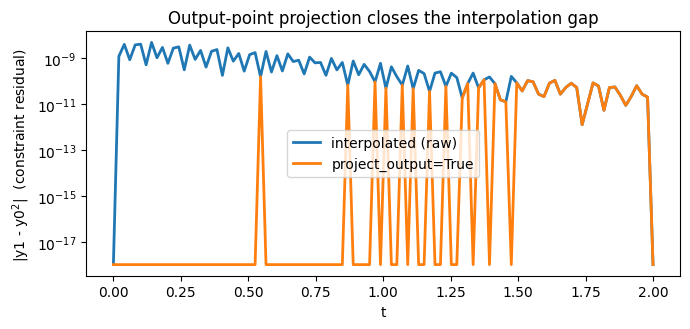

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.semilogy(te, resid_raw + 1e-18, label="interpolated (raw)", lw=2)
ax.semilogy(te, resid_proj + 1e-18, label="project_output=True", lw=2)
ax.set_xlabel("t"); ax.set_ylabel("|y1 - y0$^2$|  (constraint residual)")
ax.set_title("Output-point projection closes the interpolation gap")
ax.legend(); fig.tight_layout()

## 4. Linear constraints are already exact — projection is auto-skipped

Here is the result that keeps you from turning `project_output` on everywhere.
For a **linear** conservation law `c'y = d` (mass, atom, charge, site balance,
`sum(x) = 1`), the degree-3 dense output satisfies the constraint *exactly*: the
cubic `c'u(τ) - d` vanishes at the three collocation nodes **and** at the
on-manifold step start — four roots, so it is identically zero.

`solve_ivp` detects this (the algebraic-row Jacobian is constant) and **skips**
the projection entirely, returning bit-for-bit identical output. Robertson
kinetics, whose algebraic row is the linear `y0 + y1 + y2 = 1`:

In [7]:
k1, k2, k3 = 0.04, 3e7, 1e4
def robertson(t, y):
    return [-k1*y[0] + k3*y[1]*y[2],
            k1*y[0] - k3*y[1]*y[2] - k2*y[1]**2,
            y[0] + y[1] + y[2] - 1.0]         # LINEAR algebraic constraint

Mr = np.diag([1.0, 1.0, 0.0])
ter = np.logspace(-4, 4, 60)
base = po.solve_ivp(robertson, (0, 1e4), [1.0, 0, 0], mass=Mr,
                    rtol=1e-6, atol=1e-8, t_eval=ter)
proj = po.solve_ivp(robertson, (0, 1e4), [1.0, 0, 0], mass=Mr,
                    rtol=1e-6, atol=1e-8, t_eval=ter, project_output=True)

print("identical output (projection skipped):", np.array_equal(base.y, proj.y))
print("sum(y) - 1 max residual:", np.abs(base.y.sum(0) - 1).max())

identical output (projection skipped): True
sum(y) - 1 max residual: 2.220446049250313e-16


So the rule of thumb is simple:

| constraint | dense output | `project_output` |
|---|---|---|
| **linear** (conservation laws) | already exact | no-op, auto-skipped |
| **nonlinear** (rate/PSSH/VLE/…) | small interpolated residual | closes the gap |

Leave `project_output` **off** unless you have a nonlinear algebraic constraint
*and* have measured (with `examples/dae_manifold_gap.py`) that its **absolute**
interpolated residual is large enough to matter for what you do with the
trajectory. Both knobs compose: `consistent="project"` puts the initial point on
the manifold, `project_output=True` keeps every reported point there.